### Import needed libraries

In [57]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
import os
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV
from sklearn.covariance import EmpiricalCovariance
from scipy.stats import pearsonr
import shutil

np.random.seed(0)

### Create directories

In [58]:
# create dir for pcorr matrices & edge weights
os.makedirs('pcorr_matrices', exist_ok=True)
os.makedirs('pcorr_matrices/edge_weights', exist_ok=True)

# create dir for Graphs
os.makedirs('graphs', exist_ok=True)

# create dir for BEI
os.makedirs('BEI', exist_ok=True)

# create dir for Communites
os.makedirs('Community_distributions', exist_ok=True)

# create dir for Scatter PLots
os.makedirs('Scatter', exist_ok=True)

#create dir for Diagnostics (Q-Q plots)
os.makedirs('Diagnostics', exist_ok=True)

### Imported cleaned dataset

In [59]:
df = pd.read_csv('Form_Responses_04-02-2026_cleaned.csv')

### Descriptive Statistics (Age)

Ages: 18 - 29
Mean Age: 21.43
Median Age: 21.00
SD Age: 2.68


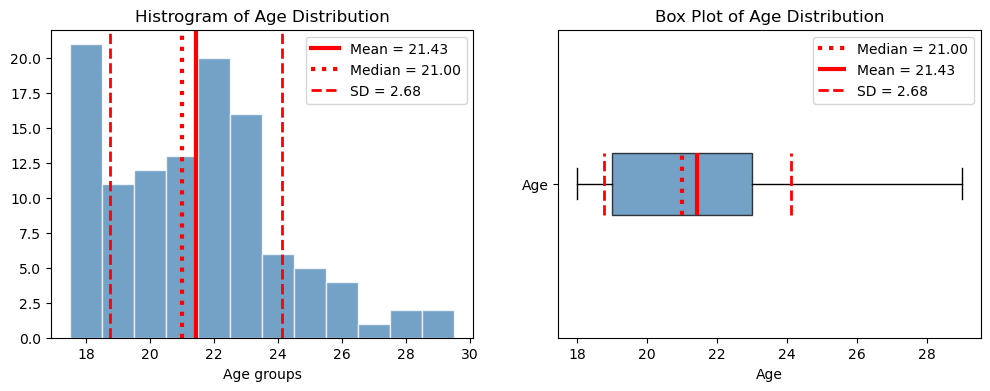

In [60]:
# Just use the numeric column directly
ages = df['Age'].dropna().to_numpy()

mean_age = np.mean(ages)
median_age = np.median(ages)
sd_age = np.std(ages, ddof=1)

print(f"Ages: 18 - 29")
print(f"Mean Age: {mean_age:.2f}")
print(f"Median Age: {median_age:.2f}")
print(f"SD Age: {sd_age:.2f}")

# Histogram plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bin edges centered around the representative values
bins = np.arange(int(np.min(ages))-0.5, int(np.max(ages))+1.5)

ax1.hist(
    ages,
    bins=bins,
    edgecolor='white',
    density=False,
    alpha=0.75,
    color='steelblue'
)

# Mean and median lines
ax1.axvline(mean_age, linestyle='-', linewidth=3, label=f"Mean = {mean_age:.2f}", color='red')
ax1.axvline(median_age, linestyle=':', linewidth=3, label=f"Median = {median_age:.2f}", color='red')

# SD range: mean ± SD
ax1.axvline(mean_age - sd_age, linestyle='--', linewidth=2, label=f"SD = {sd_age:.2f}", color='red')
ax1.axvline(mean_age + sd_age, linestyle='--', linewidth=2, color='red')

ax1.set_xlabel('Age groups')
ax1.set_title('Histrogram of Age Distribution')
ax1.legend()

# Box plot for Age
box_y = 1
box_width = 0.2
line_ymin = box_y - box_width / 2
line_ymax = box_y + box_width / 2

ax2.boxplot(
    ages,
    vert=False,
    patch_artist=True,
    widths=box_width,
    boxprops=dict(facecolor='steelblue', alpha=0.75),
    medianprops=dict(color='red',linestyle=':', linewidth=3,label=f"Median = {median_age:.2f}"),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='red', alpha=0.6)
)

# Mean line, same height as median
ax2.vlines( mean_age, ymin=line_ymin, ymax=line_ymax, linestyle='-', linewidth=3, color='red', label=f"Mean = {mean_age:.2f}")

# SD lines, same height as median
ax2.vlines(mean_age - sd_age, ymin=line_ymin, ymax=line_ymax, linestyle='--', linewidth=2, color='red', label=f"SD = {sd_age:.2f}")
ax2.vlines( mean_age + sd_age, ymin=line_ymin, ymax=line_ymax, linestyle='--', linewidth=2, color='red' )

ax2.set_xlabel('Age')
ax2.set_yticks([1], ['Age'])
ax2.set_title('Box Plot of Age Distribution')
ax2.legend()

plt.savefig('age_ditribution.png')
plt.show()

### Descriptive Statistics (BSMAS)

SMA_Salience: 2.34/5 (1.20)
SMA_Tolerance: 2.57/5 (1.25)
SMA_Mood_Modification: 2.65/5 (1.35)
SMA_Relapse: 2.83/5 (1.32)
SMA_Withdrawal: 1.74/5 (1.03)
SMA_Conflict: 2.54/5 (1.32)

BSMAS_score range: [6-27]
BSMAS_score mean: 14.67/30 (5.34)

BSMAS_true: 7
BSMAS_false: 106


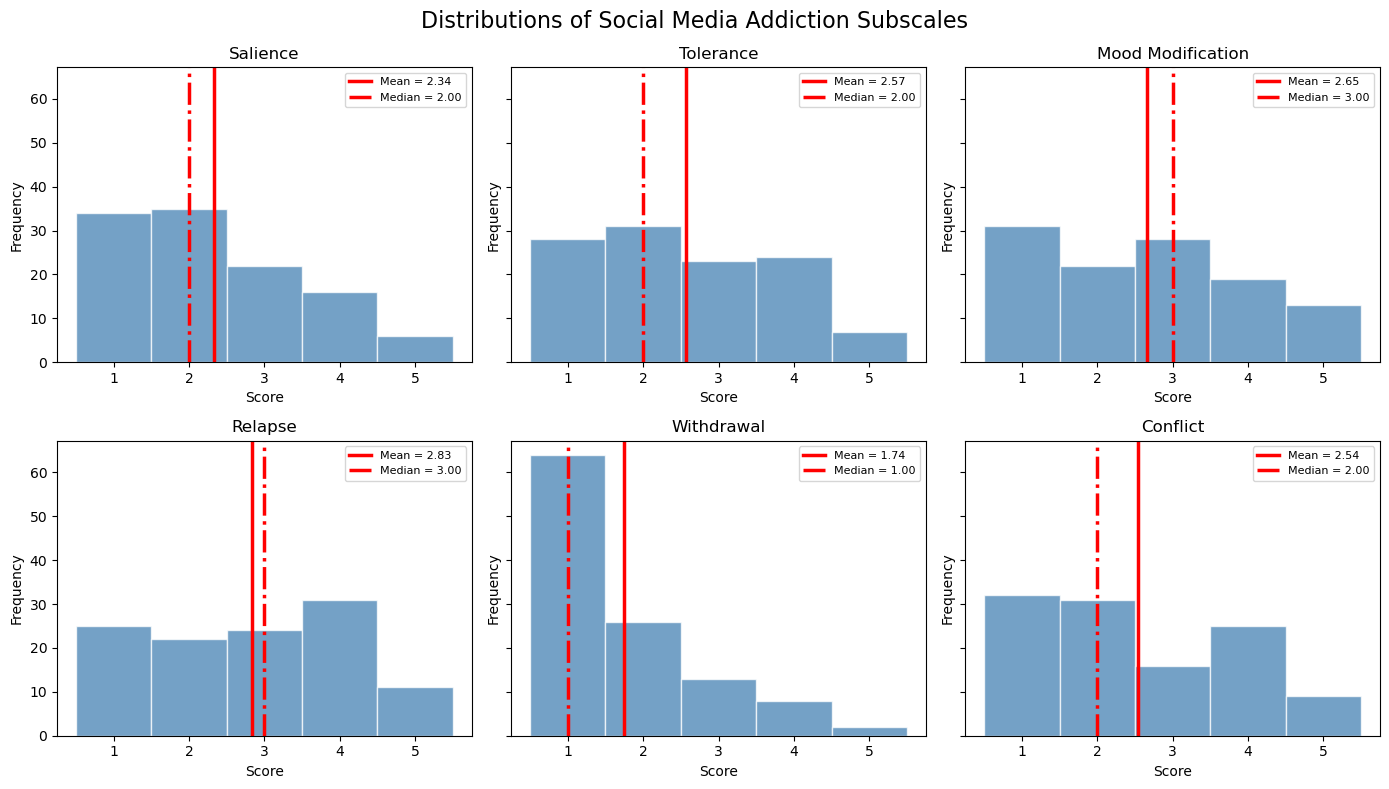

In [62]:
# Social Media Addiction (SMAs)
SMA = ['SMA_Salience', 'SMA_Tolerance', 'SMA_Mood_Modification',
       'SMA_Relapse', 'SMA_Withdrawal', 'SMA_Conflict']

# Means und SDs berechnen
sma_means = {sma: np.mean(df[sma].dropna().to_numpy()) for sma in SMA}
sma_sd = {sma: np.std(df[sma].dropna().to_numpy(), ddof=1) for sma in SMA}

for sma in SMA:
    print(f"{sma}: {sma_means[sma]:.2f}/5 ({sma_sd[sma]:.2f})")

# Caclulate overall score
BSMAS_score_mean = np.mean(df['BSMAS_score'].to_numpy())
BSMAS_score_sd = np.std(df['BSMAS_score'].to_numpy(), ddof=1)
print(f"\nBSMAS_score range: [{df['BSMAS_score'].min()}-{df['BSMAS_score'].max()}]")
print(f"BSMAS_score mean: {BSMAS_score_mean:.2f}/30 ({BSMAS_score_sd:.2f})")

BSMAS_true = len(df[df['BSMAS_score'] >= 24])
BSMAS_false = len(df[df['BSMAS_score'] < 24])
print(f"\nBSMAS_true: {BSMAS_true}")
print(f"BSMAS_false: {BSMAS_false}")


# 6-Panel Histogramm
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for ax, sma in zip(axes, SMA):
    values = df[sma].dropna().to_numpy()

    mean_val = np.mean(values)
    median_val = np.median(values)
    sd_val = np.std(values, ddof=1)

    # SMA-Skalen Likert-Werte von 1 bis 5
    bins = np.arange(0.5, 6.5, 1)

    ax.hist(
        values,
        bins=bins,
        edgecolor='white',
        alpha=0.75,
        color='steelblue'
    )

    # Mean und Median
    ax.axvline(mean_val, linestyle='-', linewidth=2.5,
               color='red', label=f"Mean = {mean_val:.2f}")
    ax.axvline(median_val, linestyle='-.', linewidth=2.5,
               color='red', label=f"Median = {median_val:.2f}")

    ax.set_title(sma.replace("SMA_", "").replace("_", " "))
    ax.set_xlabel("Score")
    ax.set_ylabel("Frequency")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.legend(fontsize=8)

plt.suptitle("Distributions of Social Media Addiction Subscales", fontsize=16)
plt.tight_layout()
plt.savefig("Community_distributions/sma_histograms.png", bbox_inches="tight")
plt.show()

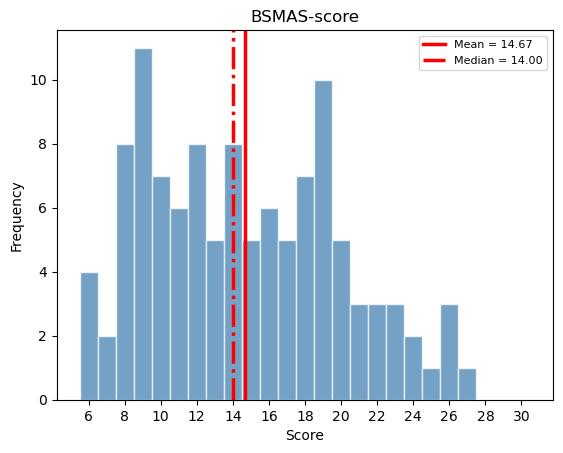

In [63]:
# Plot BSMAS-Score
values = df['BSMAS_score'].dropna().to_numpy()

mean_val = np.mean(values)
median_val = np.median(values)
sd_val = np.std(values, ddof=1)

# SMA-Skalen Likert-Werte von 1 bis 5
bins = np.arange(5.5, 31.5, 1)

plt.hist(
    values,
    bins=bins,
    edgecolor='white',
    alpha=0.75,
    color='steelblue'
)

# Mean und Median
plt.axvline(mean_val, linestyle='-', linewidth=2.5,
           color='red', label=f"Mean = {mean_val:.2f}")
plt.axvline(median_val, linestyle='-.', linewidth=2.5,
           color='red', label=f"Median = {median_val:.2f}")

plt.title('BSMAS-score')
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.xticks(range(6,31,2))
plt.legend(fontsize=8)
plt.savefig("Community_distributions/bsmas_score_histogram.png")
plt.show()


### Descriptive Statistics (Emotional Well-Being)

Tired: 3.50 (1.17)
Stressed: 3.26 (1.23)
Sad: 2.29 (1.03)
Anxious: 2.70 (1.35)
Frustrated: 2.82 (1.14)

Emotion_score range: [5-25]
Emotion_score mean: 14.58 (4.39)


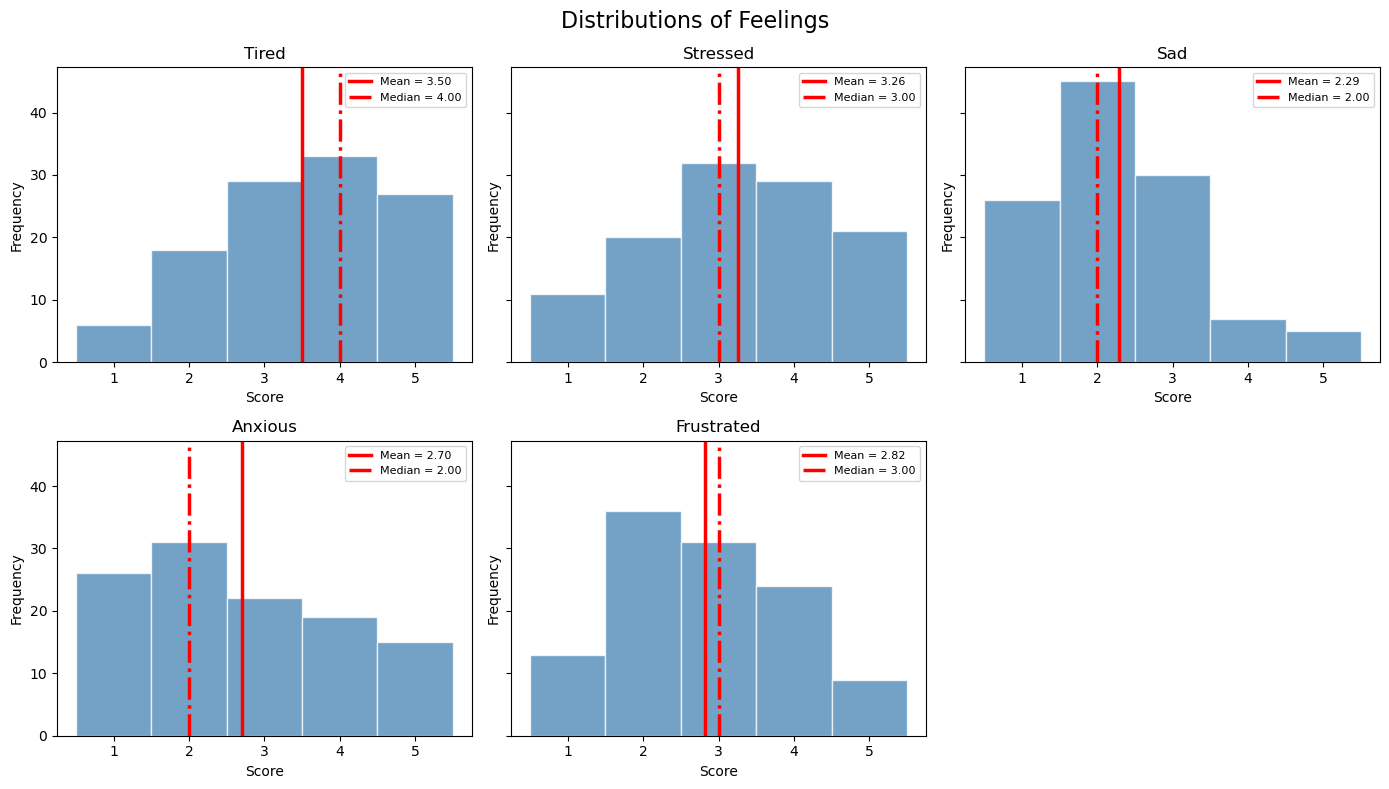

In [64]:
# Feelings
FEELINGS = ['Tired', 'Stressed', 'Sad', 'Anxious', 'Frustrated']

# Means und SDs berechnen
feeling_means = {f: np.mean(df[f].dropna().to_numpy()) for f in FEELINGS}
feeling_sd = {f: np.std(df[f].dropna().to_numpy(), ddof=1) for f in FEELINGS}

for f in FEELINGS:
    print(f"{f}: {feeling_means[f]:.2f} ({feeling_sd[f]:.2f})")

# Caclulate overall score
Emotion_score_mean = np.mean(df['Emotion_score'].to_numpy())
Emotion_score_sd = np.std(df['Emotion_score'].to_numpy(), ddof=1)
print(f"\nEmotion_score range: [{df['Emotion_score'].min()}-{df['Emotion_score'].max()}]")
print(f"Emotion_score mean: {Emotion_score_mean:.2f} ({Emotion_score_sd:.2f})")


# 5-Panel Histogramm
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for ax, feeling in zip(axes, FEELINGS):
    values = df[feeling].dropna().to_numpy()

    mean_val = np.mean(values)
    median_val = np.median(values)
    sd_val = np.std(values, ddof=1)

    # Falls die Skalen Likert-Werte von 1 bis 5 sind
    bins = np.arange(0.5, 6.5, 1)

    ax.hist(
        values,
        bins=bins,
        edgecolor='white',
        alpha=0.75,
        color='steelblue'
    )

    # Mean und Median
    ax.axvline(mean_val, linestyle='-', linewidth=2.5,
               color='red', label=f"Mean = {mean_val:.2f}")
    ax.axvline(median_val, linestyle='-.', linewidth=2.5,
               color='red', label=f"Median = {median_val:.2f}")

    ax.set_title(feeling)
    ax.set_xlabel("Score")
    ax.set_ylabel("Frequency")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.legend(fontsize=8)

# Leeres 6. Panel entfernen
for ax in axes[len(FEELINGS):]:
    ax.remove()

plt.suptitle("Distributions of Feelings", fontsize=16)
plt.tight_layout()
plt.savefig("Community_distributions/feelings_histograms.png", bbox_inches="tight")
plt.show()

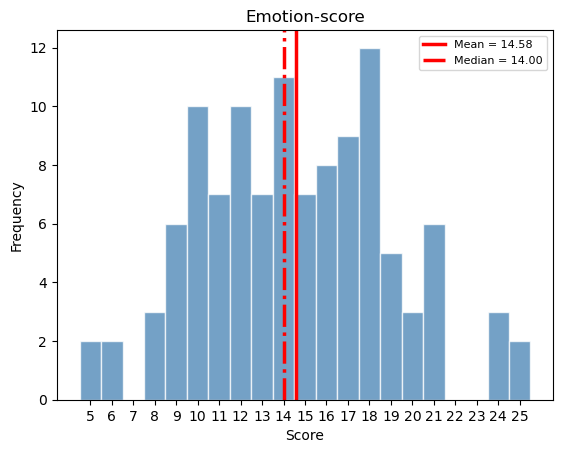

In [65]:
# Plot Emotion-Score
values = df['Emotion_score'].dropna().to_numpy()

mean_val = np.mean(values)
median_val = np.median(values)
sd_val = np.std(values, ddof=1)

# SMA-Skalen Likert-Werte von 1 bis 5
bins = np.arange(4.5, 26.5, 1)

plt.hist(
    values,
    bins=bins,
    edgecolor='white',
    alpha=0.75,
    color='steelblue'
)

# Mean und Median
plt.axvline(mean_val, linestyle='-', linewidth=2.5,
           color='red', label=f"Mean = {mean_val:.2f}")
plt.axvline(median_val, linestyle='-.', linewidth=2.5,
           color='red', label=f"Median = {median_val:.2f}")

plt.title('Emotion-score')
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.xticks(range(5,26,1))
plt.legend(fontsize=8)
plt.savefig("Community_distributions/emotion_score_histogram.png")
plt.show()

### Cronbach's $\alpha$ + Bootstrapped CI

SMA:      0.81 [0.74, 0.85] 95% BCI
FEELINGS: 0.79 [0.72, 0.84] 95% BCI

ST do not form a scale



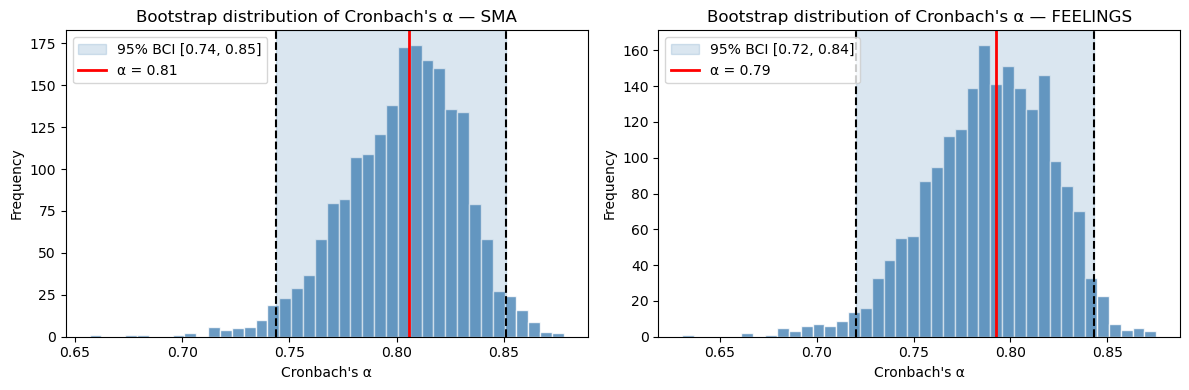

In [66]:
# Calculating Cronbach's alpha for a set of items
def cronbach_alpha(items):
    items = np.array(items)
    n, k = items.shape  # n = respondents, k = items
    item_variances = np.var(items, axis=0, ddof=1)
    total_variance = np.var(items.sum(axis=1), ddof=1)
    alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)
    return alpha

def bootstrapped_ci(data, n_bootstraps=2000, ci=0.95, seed=0):
    data = np.asarray(data)
    rng = np.random.default_rng(seed)
    n = len(data)
    alphas = np.empty(n_bootstraps)
    for i in range(n_bootstraps):
        idx = rng.integers(0, n, n)
        alphas[i] = cronbach_alpha(data[idx])
    lo = np.percentile(alphas, (1 - ci) / 2 * 100)
    hi = np.percentile(alphas, (1 + ci) / 2 * 100)
    return lo, hi, alphas  # ← also return the bootstrap distribution

# Compute alpha for each subscale
alpha_sma, (ci_sma_lo, ci_sma_hi, boots_sma) = cronbach_alpha(df[SMA].dropna()), bootstrapped_ci(df[SMA].dropna())
alpha_feelings, (ci_feel_lo, ci_feel_hi, boots_feelings) = cronbach_alpha(df[FEELINGS].dropna()), bootstrapped_ci(df[FEELINGS].dropna())

print(f"SMA:      {alpha_sma:.2f} [{ci_sma_lo:.2f}, {ci_sma_hi:.2f}] 95% BCI")
print(f"FEELINGS: {alpha_feelings:.2f} [{ci_feel_lo:.2f}, {ci_feel_hi:.2f}] 95% BCI")

# Histogram plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, boots, alpha, lo, hi, label in [
    (axes[0], boots_sma, alpha_sma, ci_sma_lo,  ci_sma_hi, "SMA"),
    (axes[1], boots_feelings, alpha_feelings, ci_feel_lo, ci_feel_hi, "FEELINGS"),
]:
    ax.hist(boots, bins=40, color='steelblue', edgecolor='white', alpha=0.8)

    # CI shading
    ax.axvspan(lo, hi, color='steelblue', alpha=0.2, label=f'95% BCI [{lo:.2f}, {hi:.2f}]')

    # Observed alpha
    ax.axvline(alpha, color='red', linestyle='-',linewidth=2, label=f'α = {alpha:.2f}')

    # CI bounds
    ax.axvline(lo, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(hi, color='black', linestyle='--', linewidth=1.5)

    ax.set_title(f"Bootstrap distribution of Cronbach's α — {label}")
    ax.set_xlabel("Cronbach's α")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.savefig("cronbach_alpha_bootstrap.png")
plt.show()

### Network Estimation (Emotional Well-Being + BSMAS)

n=113, k=11, ratio=10.3


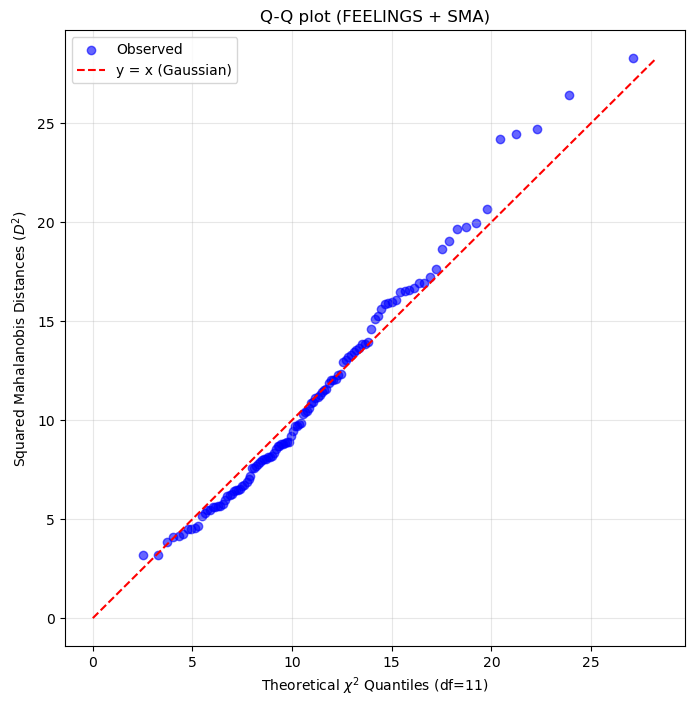

In [75]:
data = df[FEELINGS + SMA].apply(pd.to_numeric, errors='coerce').dropna()
X = StandardScaler().fit_transform(data)
n, k = X.shape
print(f"n={n}, k={k}, ratio={n/k:.1f}")

# 1. Calculate Squared Mahalanobis Distances
emp_cov = EmpiricalCovariance().fit(X)
mahal_dist = emp_cov.mahalanobis(X)  # This returns squared Mahalanobis distances (D^2)

# 2. Setup for the Chi-Square Q-Q Plot
mahal_dist_sorted = np.sort(mahal_dist)
probs = (np.arange(1, n + 1) - 0.5) / n  # plotting positions
theoretical_quantiles = stats.chi2.ppf(probs, df=k)  # theoretical quantiles for Chi-Square with k degrees of freedom

# 3. Create the Diagnostic Plot
plt.figure(figsize=(8, 8))
plt.scatter(theoretical_quantiles, mahal_dist_sorted, alpha=0.6, color='blue', label='Observed')
# Add the y=x line (where the points should be if Gaussian)
max_val = max(theoretical_quantiles.max(), mahal_dist_sorted.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='y = x (Gaussian)')
plt.xlabel(f"Theoretical $\\chi^2$ Quantiles (df={k})")
plt.ylabel("Squared Mahalanobis Distances ($D^2$)")
plt.title('Q-Q plot (FEELINGS + SMA)')
plt.legend()
plt.grid(True, alpha=0.3)
# Save the justification plot
plt.savefig('Diagnostics/feeling_sma_q-q_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [76]:
# Estimate a sparse partial‑correlation network
model = GraphicalLassoCV().fit(X)

precision = model.precision_
d = np.sqrt(np.diag(precision))
partial = -precision / np.outer(d, d)
np.fill_diagonal(partial, 1)

pcorr = pd.DataFrame(partial, index=FEELINGS + SMA, columns=FEELINGS + SMA)

# save the matrix
pcorr.to_csv("pcorr_matrices/FEELINGS-SMA_pcorr_matrix.csv")

os.makedirs('Scatter/FEELINGS-SMA_scatter_plots', exist_ok=True)

# Generate and save each scatter plot
for feeling in FEELINGS:
    for sma in SMA:
        plt.figure(figsize=(8, 6))
        plt.scatter(df[feeling], df[sma], alpha=0.5)
        plt.xlabel(feeling)
        plt.ylabel(sma)
        plt.title(f'{feeling} vs {sma}')
        plt.tight_layout()
        plt.savefig(f'Scatter/FEELINGS-SMA_scatter_plots/{feeling}_vs_{sma}.png')
        plt.close()


print(pcorr)

                          Tired  Stressed       Sad   Anxious  Frustrated  \
Tired                  1.000000  0.319349  0.000000  0.189863    0.119506   
Stressed               0.319349  1.000000  0.000000  0.225878    0.119920   
Sad                    0.000000  0.000000  1.000000  0.246070    0.115365   
Anxious                0.189863  0.225878  0.246070  1.000000    0.194091   
Frustrated             0.119506  0.119920  0.115365  0.194091    1.000000   
SMA_Salience           0.000000  0.029845  0.000000  0.000000   -0.000000   
SMA_Tolerance          0.000000  0.075939  0.048081 -0.000000   -0.000000   
SMA_Mood_Modification -0.000000  0.091039  0.246038  0.072560    0.000000   
SMA_Relapse            0.000000  0.000000 -0.000000 -0.000000    0.063193   
SMA_Withdrawal         0.000000  0.000000 -0.000000  0.110731    0.000000   
SMA_Conflict           0.050049  0.000000  0.015749  0.000000    0.030051   

                       SMA_Salience  SMA_Tolerance  SMA_Mood_Modification  

### BEI + Bootstrapped CS-Coefficient (Emotional Well-Being + BSMAS)

BEI with bootstrapped 95% CI:

Tired: 0.05  [-0.23, 0.25]
Stressed: 0.20  [0.02, 0.47]
Sad: 0.31  [0.09, 0.54]
Anxious: 0.18  [-0.06, 0.41]
Frustrated: 0.09  [-0.18, 0.25]
SMA_Salience: 0.03  [-0.13, 0.21]
SMA_Tolerance: 0.12  [-0.01, 0.32]
SMA_Mood_Modification: 0.41  [0.16, 0.61]
SMA_Relapse: 0.06  [-0.11, 0.17]
SMA_Withdrawal: 0.11  [-0.10, 0.27]
SMA_Conflict: 0.10  [-0.04, 0.33]


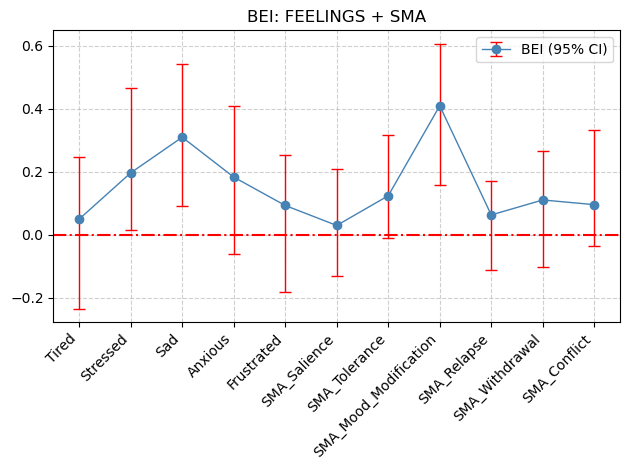

In [77]:
# Calcluating the BEI
# BEI for FEELINGS nodes: sum only edges to SMA nodes
bei_feeling = [pcorr.loc[node, SMA].sum() for node in FEELINGS]

# BEI for SMA nodes: sum only edges to FEELINGS nodes
bei_sma = [pcorr.loc[node, FEELINGS].sum() for node in SMA]

# Bootstrapped 95% CI for BEI
all_labels = FEELINGS + SMA
all_values = bei_feeling + bei_sma

bei_data_full = df[all_labels].apply(pd.to_numeric, errors='coerce').dropna()
bei_n         = len(bei_data_full)
bei_data_arr  = bei_data_full.to_numpy()
bei_rng       = np.random.default_rng(0)

def _fit_pcorr_bei(X_raw, cols):
    Xs = StandardScaler().fit_transform(X_raw)
    m  = GraphicalLassoCV().fit(Xs)
    prec = m.precision_
    d    = np.sqrt(np.diag(prec))
    pc   = -prec / np.outer(d, d)
    np.fill_diagonal(pc, 1)
    return pd.DataFrame(pc, index=cols, columns=cols)

bei_boots = {node: [] for node in all_labels}
for _ in range(100):
    idx = bei_rng.integers(0, bei_n, bei_n)
    try:
        pc_b = _fit_pcorr_bei(bei_data_arr[idx], all_labels)
        for node in all_labels:
            other = SMA if node in FEELINGS else FEELINGS
            bei_boots[node].append(pc_b.loc[node, other].sum())
    except Exception:
        pass

lo_pct = (1 - 0.95) / 2 * 100
hi_pct = (1 + 0.95) / 2 * 100
ci_lo = np.array([np.percentile(bei_boots[node], lo_pct) for node in all_labels])
ci_hi = np.array([np.percentile(bei_boots[node], hi_pct) for node in all_labels])

print("BEI with bootstrapped 95% CI:\n")
for node, val, lo, hi in zip(all_labels, all_values, ci_lo, ci_hi):
    print(f"{node}: {val:.2f}  [{lo:.2f}, {hi:.2f}]")

# plot results with CI error bars
yerr_lo = np.array(all_values) - ci_lo
yerr_hi = ci_hi - np.array(all_values)

plt.errorbar(all_labels, all_values, yerr=[yerr_lo, yerr_hi],
             fmt='o-', linewidth=1, capsize=4,
             color='steelblue', ecolor='red', label='BEI (95% CI)')

# 3. Add styling and formatting
plt.title('BEI: FEELINGS + SMA', fontsize=12)

# Rotate labels so they don't overlap
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, linestyle='-.', linewidth=1.5, color='red')
plt.legend()

plt.tight_layout()

plt.savefig('BEI/FEELINGS-SMA_BEI.png')
plt.show()

  fraction 0.95: P(r ≥ 0.7) = 1.000
  fraction 0.90: P(r ≥ 0.7) = 1.000
  fraction 0.85: P(r ≥ 0.7) = 1.000
  fraction 0.80: P(r ≥ 0.7) = 1.000
  fraction 0.75: P(r ≥ 0.7) = 0.970
  fraction 0.70: P(r ≥ 0.7) = 0.960
  fraction 0.65: P(r ≥ 0.7) = 0.930
  P(r ≥ 0.7) < 0.95 therefore test stopped

CS coefficient (BEI – FEELING+SMA): 0.3167



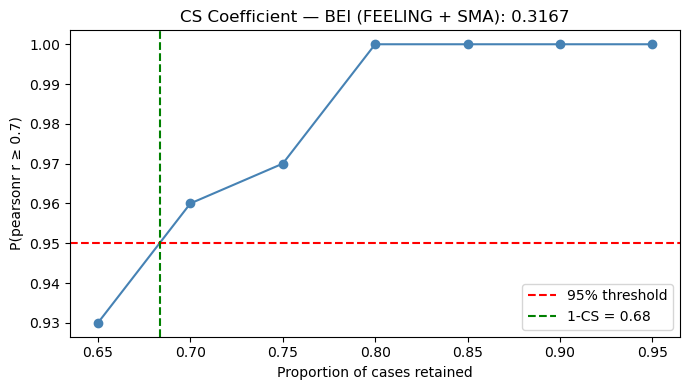

In [78]:
# CS Coefficient
full_bei   = np.array(bei_feeling + bei_sma)
data_array = df[FEELINGS + SMA].apply(pd.to_numeric, errors='coerce').dropna().to_numpy()
rng        = np.random.default_rng(0)
fractions  = np.round(np.arange(0.95, 0.05, -0.05), 2)

def compute_bei(subset_array):
    cols = FEELINGS + SMA
    X = StandardScaler().fit_transform(subset_array)
    model = GraphicalLassoCV().fit(X)
    precision = model.precision_
    d = np.sqrt(np.diag(precision))
    partial = -precision / np.outer(d, d)
    np.fill_diagonal(partial, 1)
    pcorr_sub = pd.DataFrame(partial, index=cols, columns=cols)
    return np.array(
        [pcorr_sub.loc[node, SMA].sum() if node in FEELINGS
        else pcorr_sub.loc[node, FEELINGS].sum() for node in cols]
    )

cs_results = {frac : 0 for frac in fractions}
for frac in fractions:
    subset_n = max(5, int(len(data_array) * frac))
    cors = []
    for _ in range(100):
        idx = rng.choice(len(data_array), subset_n, replace=False)
        try:
            r, _ = pearsonr(full_bei, compute_bei(data_array[idx]))
            cors.append(r)
        except Exception:
            cors.append(np.nan)
    prob = np.nanmean(np.array(cors) >= 0.7)
    cs_results[frac] = prob
    print(f"  fraction {frac:.2f}: P(r ≥ 0.7) = {prob:.3f}")

    if prob < 0.95:
        print("  P(r ≥ 0.7) < 0.95 therefore test stopped")
        break

# CS = largest fraction where all fractions >= c also meet the threshold
sorted_fracs = sorted(fractions)  # ascending: [0.1, 0.2, ..., 0.9]

# Find smallest frac where ALL fracs >= it pass the threshold
cs_frac = 0.0
for frac in sorted_fracs:  # ascending: 0.1, 0.2, ..., 0.9
    if all(cs_results[f] >= 0.95 for f in sorted_fracs if f >= frac):
        cs_frac = frac  # take the first (smallest) one that satisfies this
        break           # stop immediately — don't keep updating

# Interpolate between cs_frac (first pass) and the next fraction (last fail)
passing = [f for f in sorted_fracs if cs_results[f] >= 0.95]
failing = [f for f in sorted_fracs if cs_results[f] < 0.95]

if not failing:
    cs = 1 - sorted_fracs[0]   # all passed
elif not passing:
    cs = 0.0
else:
    f_pass = min(passing)
    f_fail = max(failing)

    p_pass = cs_results[f_pass]
    p_fail = cs_results[f_fail]

    # interpolate the retained-fraction where P = 0.95
    f_cross = f_fail + (f_pass - f_fail) * (0.95 - p_fail) / (p_pass - p_fail)
    cs = round(1 - f_cross, 4)  # CS = proportion that can be dropped

print(f"\nCS coefficient (BEI – FEELING+SMA): {cs}\n")

# CS plot
fracs = sorted(cs_results.keys())
probs = [cs_results[f] for f in fracs]

fracs_nz = [f for f, p in zip(fracs, probs) if p > 0]
probs_nz = [p for p in probs if p > 0]

plt.figure(figsize=(7, 4))
plt.plot(fracs_nz, probs_nz, marker='o', color='steelblue')
plt.axhline(0.95, color='red',   linestyle='--', label='95% threshold')
plt.axvline(1-cs, color='green', linestyle='--', label=f'1-CS = {1-cs:.2f}')
plt.xlabel("Proportion of cases retained")
plt.ylabel("P(pearsonr r ≥ 0.7)")
plt.title(f"CS Coefficient — BEI (FEELING + SMA): {cs}")
plt.legend()
plt.tight_layout()
plt.savefig('BEI/FEELING-SMA_CS_coefficient.png')
plt.show()

### Edges + Bootstrapped CI (Emotional Well-Being + BSMAS)

In [79]:
# Identify cross‑community edges
edges = []
nodes = FEELINGS + SMA
for index_i, i in enumerate(nodes):
    for index_j, j in enumerate(nodes):
        if index_j < index_i:
            w = pcorr.loc[i, j]
            if abs(w) > 0:
                edges.append((i, j, float(w)))

# Full-sample data
data_full = df[FEELINGS + SMA].apply(pd.to_numeric, errors='coerce').dropna()
n = len(data_full)
data_arr = data_full.to_numpy()
all_cols = FEELINGS + SMA

def fit_pcorr(X_raw):
    """Standardise → GraphicalLassoCV → partial-correlation matrix."""
    X = StandardScaler().fit_transform(X_raw)
    m = GraphicalLassoCV().fit(X)
    prec = m.precision_
    d = np.sqrt(np.diag(prec))
    pc = -prec / np.outer(d, d)
    np.fill_diagonal(pc, 1)
    return pd.DataFrame(pc, index=all_cols, columns=all_cols)

# Bootstrap distribution for every edge
edge_boots = {(i, j): [] for i, j, _ in edges}

for b in range(100):
    idx = rng.integers(0, n, n)
    boot_arr = data_arr[idx]
    try:
        pc_boot = fit_pcorr(boot_arr)
        for i, j, _ in edges:
            edge_boots[(i, j)].append(pc_boot.loc[i, j])
    except Exception:
        pass

# Print results
lo_pct = (1 - 0.95) / 2 * 100
hi_pct = (1 + 0.95) / 2 * 100

table_rows = []

for i, j, w in edges:
    vals = np.array(edge_boots[(i, j)])
    lo = np.percentile(vals, lo_pct)
    hi = np.percentile(vals, hi_pct)

    table_rows.append({"Edge": f"{i} <-> {j}",
                       "r": w,
                       "CI_lo": lo,
                       "CI_hi": hi})

df_feeling_sma = pd.DataFrame(table_rows)
df_feeling_sma = df_feeling_sma.set_index("Edge")

df_feeling_sma.to_csv("pcorr_matrices/edge_weights/feeling_sma_weights.csv", index=False)

print(f"Bootstrapped 95% CI for FEELINGS–SMA partial correlations\n")
print(df_feeling_sma.sort_values(by='r'))

/opt/homebrew/Caskroom/miniconda/base/envs/ans/lib/python3.10/site-packages/numpy/_core/_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Bootstrapped 95% CI for FEELINGS–SMA partial correlations

                                                 r     CI_lo     CI_hi
Edge                                                                  
SMA_Conflict <-> Sad                      0.015749 -0.016527  0.220612
SMA_Salience <-> Stressed                 0.029845 -0.029741  0.184725
SMA_Conflict <-> Frustrated               0.030051 -0.141608  0.166384
SMA_Conflict <-> SMA_Withdrawal           0.047721 -0.043989  0.226397
SMA_Tolerance <-> Sad                     0.048081  0.000000  0.276734
SMA_Conflict <-> Tired                    0.050049 -0.019269  0.211784
SMA_Mood_Modification <-> SMA_Salience    0.053642 -0.026605  0.253301
SMA_Conflict <-> SMA_Tolerance            0.056569 -0.039628  0.215208
SMA_Relapse <-> Frustrated                0.063193  0.000000  0.266805
SMA_Mood_Modification <-> Anxious         0.072560 -0.008850  0.265255
SMA_Tolerance <-> Stressed                0.075939  0.000000  0.263241
SMA_Mood_Modificat

In [80]:
# build a NetworkX graph and export to GraphML for visone
G = nx.Graph()

# add nodes with a 'group' attribute so you can color ST vs SMA differently in visone
nodes = FEELINGS + SMA
for n in nodes:
    group = "FEELINGS" if n in FEELINGS else "SMA"
    G.add_node(n, label=n, group=group)


# add edges with attributes visone can map to width and color
# add edges with attributes visone can map to width and color
edges = []
for edge_name, row in df_feeling_sma.iterrows():
    i, j = edge_name.split(" <-> ")
    w = row["r"]

    if abs(w) > 0:
        edges.append((i, j, float(w)))

for i, j, w in edges:
    G.add_edge(
        i, j,
        pcorr=w,            # raw signed value (use for diverging color scheme)
        abs_pcorr=abs(w),   # use this for edge thickness
        sign="pos" if w > 0 else "neg",  # use this for categorical red/green
    )

nx.write_graphml(G, "graphs/FEELINGS-SMA_pcorr_network.graphml")
print(f"Saved {G.number_of_nodes()} nodes and {G.number_of_edges()} edges to FEELINGS-SMA_pcorr_network.graphml")

Saved 11 nodes and 31 edges to FEELINGS-SMA_pcorr_network.graphml


In [81]:
# Filter for only significant edge weihts
df_feeling_sma = df_feeling_sma[(df_feeling_sma['CI_lo'] > 0) | (df_feeling_sma['CI_hi'] < 0)]

df_feeling_sma.to_csv("pcorr_matrices/edge_weights/feeling_sma_weights_sig.csv", index=False)

print(f"Significant Feeling–SMA partial correlations \n")
print(df_feeling_sma.sort_values(by='r'))

Significant Feeling–SMA partial correlations 

                                               r     CI_lo     CI_hi
Edge                                                                
Frustrated <-> Stressed                 0.119920  0.003696  0.259706
SMA_Withdrawal <-> SMA_Tolerance        0.130296  0.000955  0.275700
SMA_Withdrawal <-> SMA_Relapse          0.153099  0.006165  0.284944
SMA_Conflict <-> SMA_Mood_Modification  0.159882  0.010884  0.362043
SMA_Withdrawal <-> SMA_Salience         0.161985  0.018815  0.343291
Anxious <-> Tired                       0.189863  0.050691  0.348522
Frustrated <-> Anxious                  0.194091  0.034006  0.377500
Anxious <-> Stressed                    0.225878  0.084151  0.391694
SMA_Mood_Modification <-> Sad           0.246038  0.104669  0.392966
Anxious <-> Sad                         0.246070  0.115675  0.414549
SMA_Tolerance <-> SMA_Salience          0.262328  0.119673  0.442918
Stressed <-> Tired                      0.319349  0.1924

In [82]:
# build a NetworkX graph and export to GraphML for visone
G = nx.Graph()

# add nodes with a 'group' attribute so you can color ST vs SMA differently in visone
nodes = FEELINGS + SMA
for n in nodes:
    group = "FEELINGS" if n in FEELINGS else "SMA"
    G.add_node(n, label=n, group=group)

# add edges with attributes visone can map to width and color
edges = []
for edge_name, row in df_feeling_sma.iterrows():
    i, j = edge_name.split(" <-> ")
    w = row["r"]

    if abs(w) > 0:
        edges.append((i, j, float(w)))

# add edges with attributes visone can map to width and color
for i, j, w in edges:
    G.add_edge(
        i, j,
        pcorr=w,            # raw signed value (use for diverging color scheme)
        abs_pcorr=abs(w),   # use this for edge thickness
        sign="pos" if w > 0 else "neg",  # use this for categorical red/green
    )

nx.write_graphml(G, "graphs/FEELINGS-SMA_pcorr_network_SIG.graphml")
print(f"Saved {G.number_of_nodes()} nodes and {G.number_of_edges()} edges to FEELINGS-SMA_pcorr_network_NT.graphml")

Saved 11 nodes and 14 edges to FEELINGS-SMA_pcorr_network_NT.graphml


### Zip directories

In [ ]:
shutil.make_archive('APPS-SMA_scatter_plots', 'zip', 'APPS-SMA_scatter_plots')
shutil.make_archive('FEELINGS-SMA_scatter_plots', 'zip', 'FEELINGS-SMA_scatter_plots')
shutil.make_archive('ST-SMA_scatter_plots', 'zip', 'ST-SMA_scatter_plots')
shutil.make_archive('ST-FEELINGS_scatter_plots', 'zip', 'ST-FEELINGS_scatter_plots')
shutil.make_archive('pcorr_matrices', 'zip', 'pcorr_matrices')
shutil.make_archive('graphs', 'zip', 'graphs')
shutil.make_archive('BEI', 'zip', 'BEI')
shutil.make_archive('Community_distributions', 'zip', 'Community_distributions')